<a href="https://colab.research.google.com/github/kararei/databusters_lesgo/blob/main/NUS_DSESC_DATABUSTERS_XX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1) Libraries Installation
##### The cell below is to help you keep track the libraries used and install them quickly.
##### Ensure the correct library names are used, and follow the syntax: **%pip install PACKAGE_NAME**.

In [ ]:
%pip install pandas
%pip install matplotlib
%pip install numpy
%pip install seaborn
# add commented pip installation lines for packages used as shown above for ease of testing
# the line should follow the format %pip install PACKAGE_NAME

## 2) Main Section for Code
### **ALL code for machine learning and dataset analysis** should be entered below.
##### Ensure that your code is clear and readable.
##### Remember to include comments and markdown notes as necessary to explain and highlight important segments of your code.

In [ ]:
###...code...###
import pandas

monthly_data = pandas.read_csv('Monthly Data.csv')
quarterly_data = pandas.read_csv('Quarterly Data.csv')
variable_desc = pandas.read_csv('Variable Description.csv', encoding='ISO-8859-1') # convert to utf-8 encoding




# Main idea: start with quarterly to see the bigger trends - only afterwards, confirm the trends using the smaller monthly datasets



#columns to inspect for quarterly
columns_of_interest = ["sasdate", "GDPC1", "PCECC96", "GPDIC1", "GCEC1", "UNRATE", "CIVPART", "HOUST", "EXPGSC1", "IMPGSC1", "VIXCLSx", "CPIAUCSL", "FEDFUNDS", "UMCSENTx", "M2REAL", "INDPRO"]
# sasdate = mm/dd/yyyy
# GDPC1 = real gdp growth
# PCECC96 = real personal consumption expenditure
# GPDIC1 = gross private domestic investment
# GCEC1 = government expenditure
# UNRATE = unemployment rate
# CIVPART = labor force participation rate
# HOUST = private housing started
# EXPGSC1 = exports of g&s
# IMPGSC1 = imports of g&s
# VIXCLSx = stock market volatility index
# CPIAUCSL = consumer price index (inflation)
# FEDFUNDS = federal funds rate (interest rates)
# UMCSENTx = university of michigan consumer sentiment index
# M2REAL = money supply
# INDPRO = industrial production index

exists = [col for col in columns_of_interest if col in quarterly_data.columns]
quarterly_data = quarterly_data[exists]

# drop first two rows of the quarterly data
quarterly_data = quarterly_data.iloc[2:]

quarterly_data = quarterly_data.rename(columns={
    "sasdate": "date",
    "GDPC1": "real_gdp_growth",
    "PCECC96": "real_personal_consumption_expenditure",
    "GPDIC1": "gross_private_domestic_investment",
    "GCEC1": "government_expenditure",
    "UNRATE": "unemployment_rate",
    "CIVPART": "labor_force_participation_rate",
    "HOUST": "private_housing_started",
    "EXPGSC1": "exports_goods_services",
    "IMPGSC1": "imports_goods_services",
    "VIXCLSx": "stock_market_volatility",
    "CPIAUCSL": "consumer_price_index",
    "FEDFUNDS": "federal_funds_rate",
    "UMCSENTx": "consumer_sentiment_index",
    "M2REAL": "money_supply",
    "INDPRO": "industrial_production_index"
})

# convert date from String to datetime
quarterly_data["date"] = pandas.to_datetime(quarterly_data["date"], format="%m/%d/%Y") # do we need to do this for easier regression models?

quarterly_data

,date,real_gdp_growth,real_personal_consumption_expenditure,gross_private_domestic_investment,government_expenditure,unemployment_rate,labor_force_participation_rate,private_housing_started,exports_goods_services,imports_goods_services,stock_market_volatility,consumer_price_index,federal_funds_rate,consumer_sentiment_index,money_supply,industrial_production_index
2,1959-03-01,3352.129,2039.017,354.894,1142.671,5.8333,59.2000,1648.0000,89.697,115.440,NaN,28.9933,2.5700,NaN,992.7667,22.3558
3,1959-06-01,3427.667,2070.508,382.500,1156.740,5.1000,59.2667,1530.3333,88.981,121.057,NaN,29.0433,3.0833,95.3,1005.8333,23.4400
4,1959-09-01,3430.057,2092.138,357.798,1166.589,5.2667,59.3000,1505.6667,97.562,122.212,NaN,29.1933,3.5767,NaN,1014.3000,22.4813
5,1959-12-01,3439.832,2094.495,369.442,1157.052,5.6000,59.3333,1457.3333,92.734,119.109,NaN,29.3700,3.9900,93.8,1011.7000,22.5888
6,1960-03-01,3517.181,2114.532,406.581,1137.363,5.1333,58.9000,1357.3333,104.686,123.608,NaN,29.3967,3.9333,100.0,1015.8667,23.9508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,2023-09-01,22780.933,15646.695,4237.303,3836.304,3.7000,62.7333,1380.3333,2521.467,3460.391,14.9665,306.0343,5.2600,69.6,6772.6667,103.1585
261,2023-12-01,22960.600,15781.367,4244.835,3870.720,3.7333,62.6667,1481.0000,2559.591,3496.290,15.2631,308.0990,5.3300,64.9,6714.7000,102.6986
262,2024-03-01,23053.545,15856.867,4282.515,3887.718,3.8000,62.5667,1407.0000,2571.763,3548.749,13.6316,310.9897,5.3300,78.4,6683.0667,102.2428
263,2024-06-01,23223.906,15967.266,4369.185,3917.049,4.0000,62.6000,1340.3333,2578.386,3614.047,13.9525,313.1603,5.3300,71.5,6691.0000,102.8633


In [ ]:
# percentage change for numerical columns (excluding 'date')
quarterly_data_pct_change = quarterly_data.set_index("date").pct_change() * 100

# drop the first row with NaN values
quarterly_data_pct_change = quarterly_data_pct_change.iloc[1:]

# add the date column back
quarterly_data_pct_change = quarterly_data_pct_change.reset_index()

quarterly_data_pct_change


<ipython-input-31-06caf1b92826>:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  quarterly_data_pct_change = quarterly_data.set_index("date").pct_change() * 100


,date,real_gdp_growth,real_personal_consumption_expenditure,gross_private_domestic_investment,government_expenditure,unemployment_rate,labor_force_participation_rate,private_housing_started,exports_goods_services,imports_goods_services,stock_market_volatility,consumer_price_index,federal_funds_rate,consumer_sentiment_index,money_supply,industrial_production_index
0,1959-06-01,2.253434,1.544421,7.778661,1.231238,-12.570929,0.112669,-7.139970,-0.798243,4.865731,NaN,0.172454,19.972763,NaN,1.316180,4.849748
1,1959-09-01,0.069727,1.044671,-6.458039,0.851445,3.268627,0.056187,-1.611845,9.643632,0.954096,NaN,0.516470,16.002335,0.000000,0.841760,-4.090017
2,1959-12-01,0.284981,0.112660,3.254350,-0.817512,6.328441,0.056155,-3.210100,-4.948648,-2.539031,NaN,0.605276,11.555344,-1.573977,-0.256334,0.478175
3,1960-03-01,2.248627,0.956651,10.052728,-1.701652,-8.333929,-0.730281,-6.861848,12.888477,3.777212,NaN,0.090909,-1.421053,6.609808,0.411851,6.029537
4,1960-06-01,-0.538357,1.261414,-9.320406,1.126026,1.948065,1.131919,-6.507856,2.868578,0.743479,NaN,0.600748,-6.015305,-6.700000,0.223120,-2.169865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,2023-09-01,1.071523,0.631372,2.433647,1.391539,3.737348,0.212939,-5.153459,1.197286,1.143789,-8.746418,0.846090,5.410822,11.717496,-1.037456,0.288250
258,2023-12-01,0.788673,0.860706,0.177755,0.897113,0.900000,-0.106164,7.292927,1.511977,1.037426,1.981759,0.674663,1.330798,-6.752874,-0.855892,-0.445819
259,2024-03-01,0.404802,0.478412,0.887667,0.439143,1.786623,-0.159574,-4.996624,0.475545,1.500419,-10.689178,0.938237,0.000000,20.801233,-0.471105,-0.443823
260,2024-06-01,0.738980,0.696222,2.023811,0.754453,5.263158,0.053223,-4.738216,0.257528,1.840029,2.354089,0.697965,0.000000,-8.801020,0.118707,0.606889


#### Remember to rename your file name to **NUS_DSESC_DATABUSTERS_XX.ipynb** and ensure that it can run successfully. Good luck and have fun!

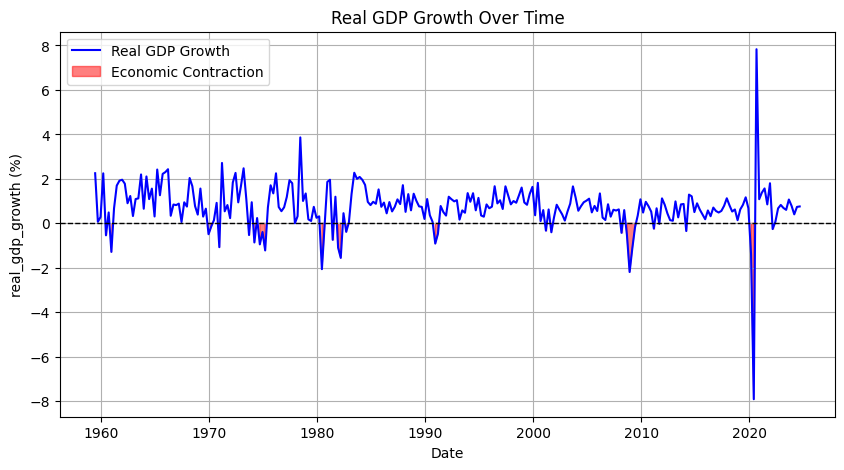

In [ ]:
import matplotlib.pyplot as plt

# add column to identify the contractions
quarterly_data_pct_change["economic_contraction"] = quarterly_data_pct_change["real_gdp_growth"] < 0

plt.figure(figsize=(10, 5))
plt.plot(quarterly_data_pct_change["date"], quarterly_data_pct_change["real_gdp_growth"], label="Real GDP Growth", color='b')

# highlight contraction
plt.fill_between(
    quarterly_data_pct_change["date"],
    quarterly_data_pct_change["real_gdp_growth"],
    where=quarterly_data_pct_change["economic_contraction"],
    color='red',
    alpha=0.5,
    label="Economic Contraction"
)

plt.axhline(0, color='black', linestyle='dashed', linewidth=1)  # 0% growth line
plt.title("Real GDP Growth Over Time")
plt.xlabel("Date")
plt.ylabel("real_gdp_growth (%)")
plt.legend()
plt.grid(True)
plt.show()


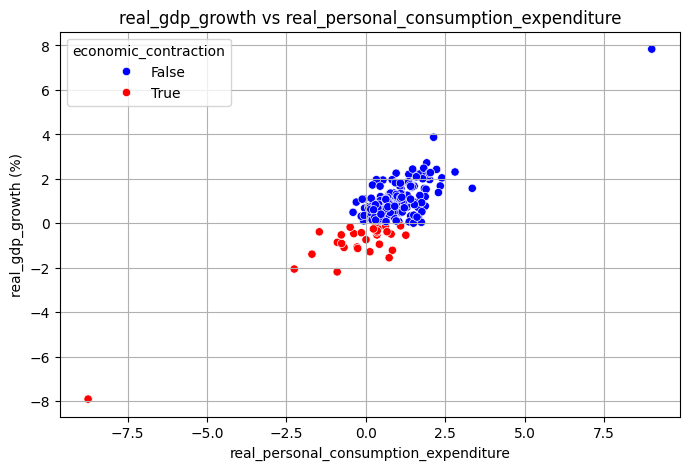

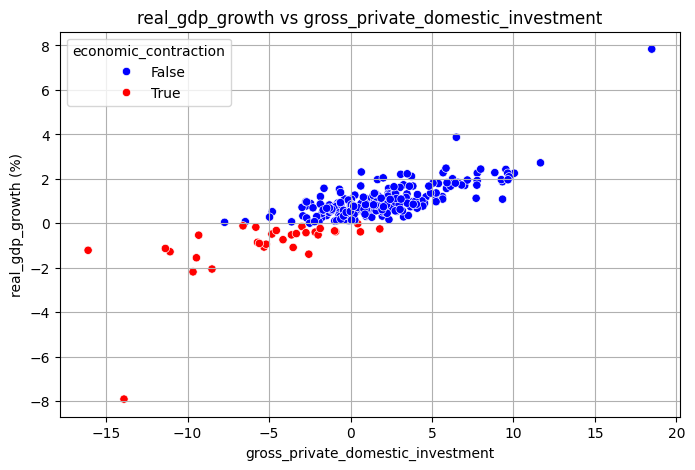

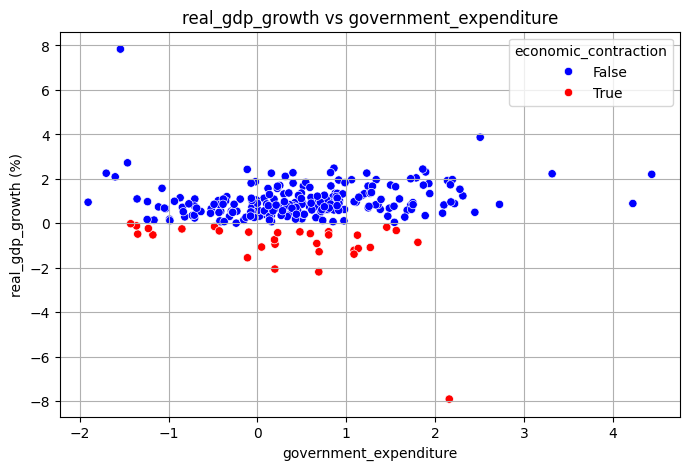

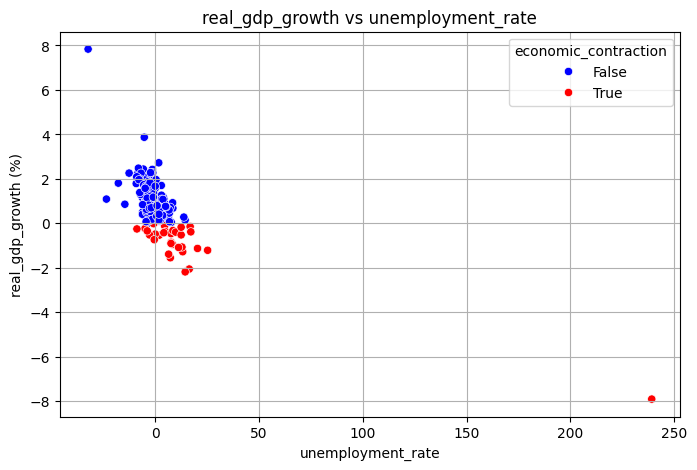

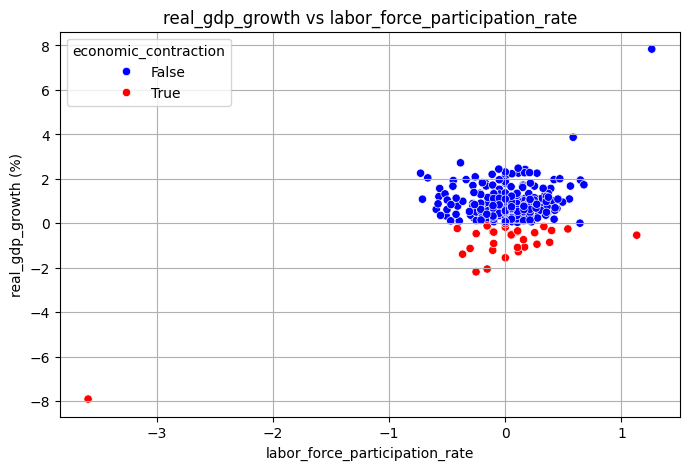

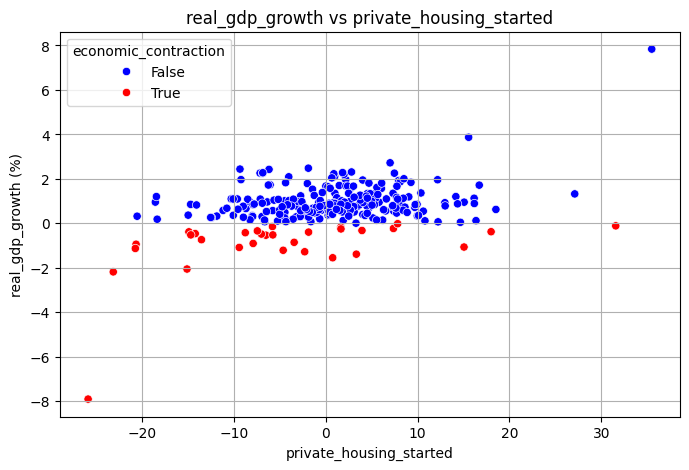

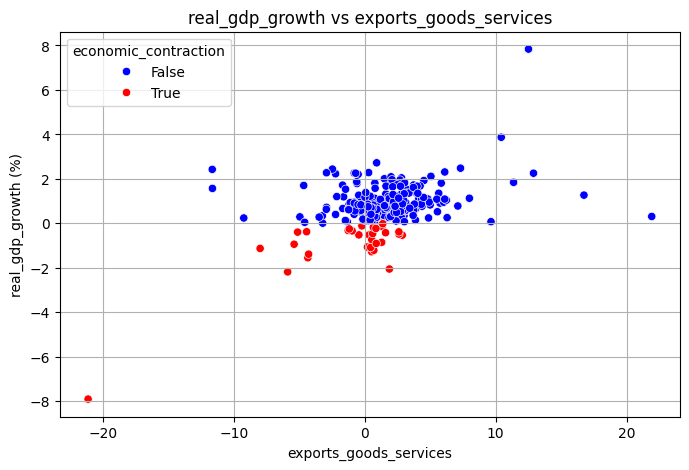

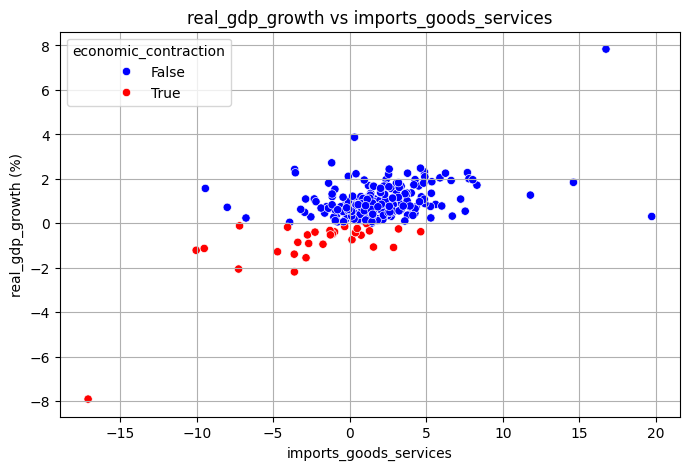

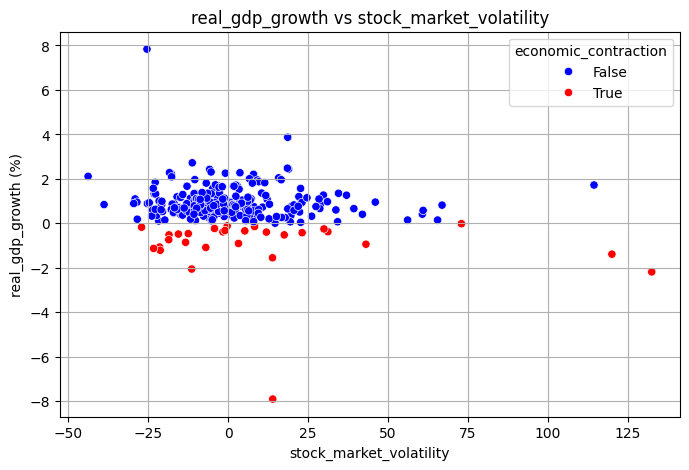

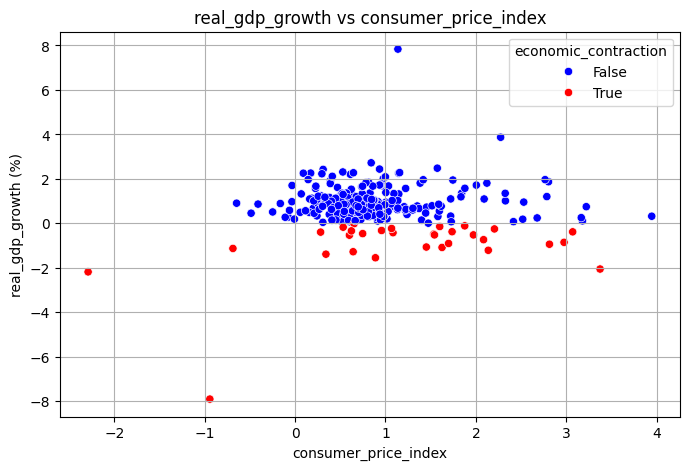

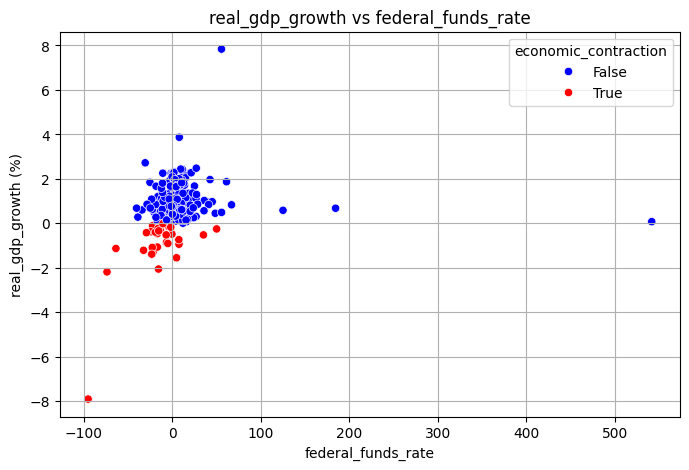

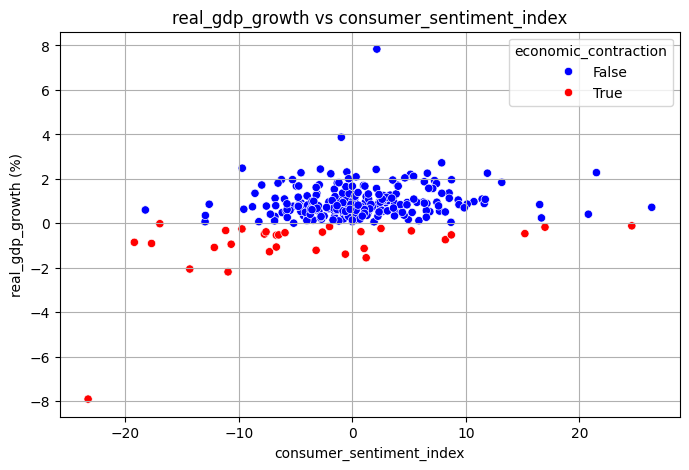

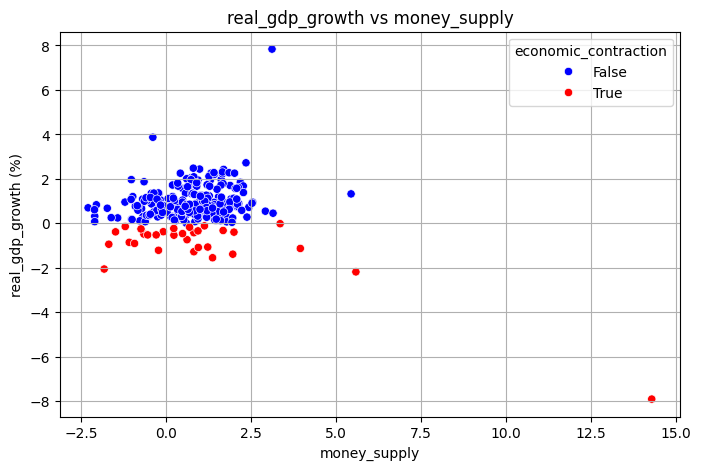

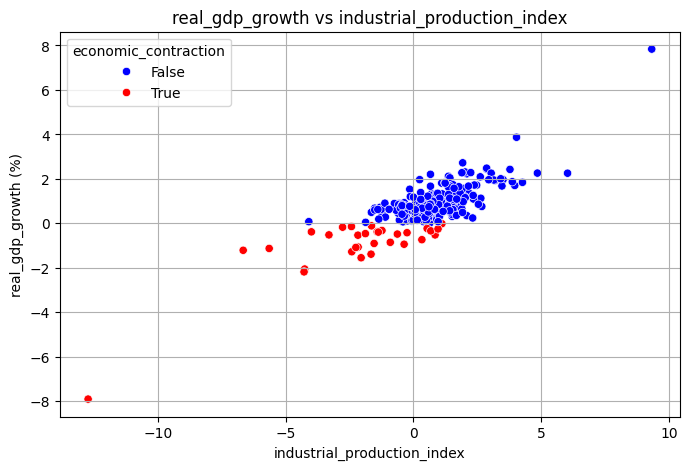

In [ ]:
import seaborn as sns

# Select key indicators (remove date and GDP itself)
indicators = [col for col in quarterly_data_pct_change.columns if col not in ["date", "real_gdp_growth", "economic_contraction"]]

# Scatter plots of GDP growth vs each indicator
for col in indicators:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=quarterly_data_pct_change[col], y=quarterly_data_pct_change["real_gdp_growth"], hue=quarterly_data_pct_change["economic_contraction"], palette={True: 'red', False: 'blue'})

    plt.xlabel(col)
    plt.ylabel("real_gdp_growth (%)")
    plt.title(f"real_gdp_growth vs {col}")
    plt.grid(True)
    plt.show()


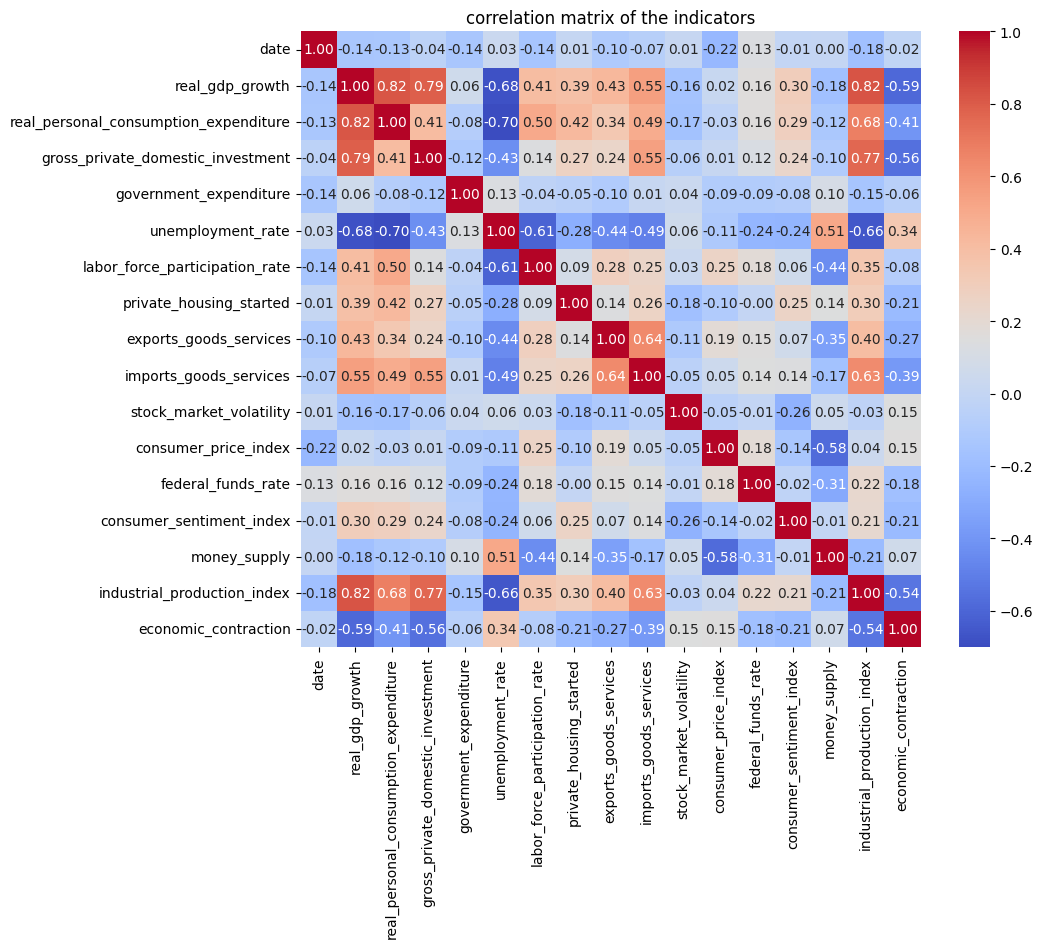

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(quarterly_data_pct_change.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("correlation matrix of the indicators")
plt.show()
